---
title: "Boosting Model 1"
author: Karisa Kopecek
date: today
format:
  html:
    embed-resources: true
    echo: true
---

## Methodology

**Model: XGBoost**
**Target:** `Irrigation_Need` (Low / Medium / High)  
**Metric:** Weighted F1 because of imbalanced data (see earlier EDA file done)
**Goal:** Test how different hyperparameter configurations actually change XGBoost performance and continue to tune with Optuna

## Setup and loading data and features

In [1]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

# using this code to make future steps easier and so I remeber my categories and seed for plots etc

SEED   = 42
TARGET = 'Irrigation_Need'
ORDER  = ['Low', 'Medium', 'High']
CAT_COLS = ['Soil_Type','Crop_Type','Crop_Growth_Stage','Season',
            'Irrigation_Type','Water_Source','Mulching_Used','Region']

In [2]:
#loading data and then choosing same features as previously used
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

for df in [train, test]:
    df['stage_mulch']   = df['Crop_Growth_Stage'].astype(str) + '_' + df['Mulching_Used'].astype(str)
    # interaction between growth stage and mulching 

    df['stress_index']  = (df['Temperature_C'] + df['Wind_Speed_kmh']) / (df['Soil_Moisture'] + 1)
    # higher temp + wind + lower moisture = higher irrigation stress

    df['water_deficit'] = df['Temperature_C'] / (df['Rainfall_mm'] / 100 + 1)
    # evaporation and rainfall supply

FEAT_CATS = CAT_COLS + ['stage_mulch']

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[FEAT_CATS] = oe.fit_transform(train[FEAT_CATS])
test[FEAT_CATS]  = oe.transform(test[FEAT_CATS])

le = LabelEncoder()
y  = le.fit_transform(train[TARGET])

FEAT_COLS = [c for c in train.columns if c not in ['id', TARGET]]
X      = train[FEAT_COLS].values
X_test = test[FEAT_COLS].values

print(f'Features: {len(FEAT_COLS)}, Train rows: {len(X):,}')

Features: 22, Train rows: 630,000


In [3]:
# using the same CV method as in previous notebooks to keep results consistant
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

sample_idx = np.random.RandomState(SEED).choice(len(X), 30000, replace=False)
X_s, y_s   = X[sample_idx], y[sample_idx]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_s, y_s, test_size=0.2, stratify=y_s, random_state=SEED)

print(f'CV sample: {len(X_s):,} rows, hold-out val: {len(X_val):,} rows')

CV sample: 30,000 rows, hold-out val: 6,000 rows


## Hyperparameters

Three hyperparameter methods are tested before Optuna is implemented. (I also tested other ones but these are the 3 I ended up with the worked the best, didn't want this homeork to be too messy and long, so got rid of the lower preforming ones.)

**Config A (min child set)**
max_depth=7, learning_rate=0.07, n_estimators=450, subsample=0.7, colsample_bytree=0.75, reg_alpha=0.2, reg_lambda=2.0, min_child_weight=5. This config combines deeper trees with both L1 and L2 regularization and a min_child_weight of 5. The min_child_weight requires at least 5 weighted samples to create a leaf, which helps with the High class imbalance (3.3% of data).

**Config B (Leaf-wise Growth)**
max_depth=0, learning_rate=0.1, n_estimators=350, subsample=0.75, colsample_bytree=0.75, min_child_weight=5, grow_policy='lossguide', max_leaves=64. XGBoost's default builds trees level by level. This config switches to leaf-wise growth using grow_policy='lossguide', which always splits whichever leaf has the highest loss reduction next (found this method was tried by others online and decided to try myself). This is similar to how LightGBM works, so this config tests whether that strategy helps XGBoost on this dataset. max_leaves=64 controls complexity.

**Config C (Deeper and Aggressive Subsampling)**
max_depth=7, learning_rate=0.1, n_estimators=350, subsample=0.65, colsample_bytree=0.7, min_child_weight=5, reg_lambda=1.5. Goes deeper to capture more complex feature interactions but compensates with more aggressive row and column subsampling (65% and 70%). Maybe subsampling alone can work.

In [4]:
configs = {
    'Config A (Deep + Reg + min_child)': dict(
        max_depth=7, learning_rate=0.07, n_estimators=450,
        subsample=0.7, colsample_bytree=0.75,
        gamma=0, reg_alpha=0.2, reg_lambda=2.0,
        min_child_weight=5
        # combines C's deeper trees + min_child_weight with B's L1/L2 regularization
        # slower learning rate with more trees to compensate — tests if the two
        # approaches reinforce each other or if one cancels out the other's gains
    ),
    'Config B (Leaf-wise Growth)': dict(
    max_depth=0, learning_rate=0.1, n_estimators=350,
    subsample=0.75, colsample_bytree=0.75,
    gamma=0, reg_alpha=0, reg_lambda=1.5,
    min_child_weight=5,
    grow_policy='lossguide', max_leaves=64
    # XGBoost default is depthwise — it builds trees level by level
    # lossguide switches to leaf-wise growth like LightGBM: always splits
    # the leaf with the highest loss reduction first
    # max_leaves=64 controls complexity instead of max_depth (set to 0 to disable)
    # this is a fundamentally different algorithm, not just a parameter tweak
    ),
    'Config C (Deeper + Aggressive Subsample + min_child)': dict(
        max_depth=7, learning_rate=0.1, n_estimators=350,
        subsample=0.65, colsample_bytree=0.7,
        gamma=0, reg_alpha=0, reg_lambda=1.5,
        min_child_weight=5
        # one level deeper than A/B, offset by more aggressive subsampling
        # min_child_weight=5 prevents splits on very few minority (High) samples
    ),
}

def cv_weighted_f1(model, X, y, cv):
    # cross_val_score dropped fit_params in newer sklearn
    # so we loop over folds manually and pass sample_weight directly to fit()
    fold_scores = []
    for tr_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        sw = compute_sample_weight('balanced', y_tr)
        # compute weights on the training fold only (not the full sample)
        model.fit(X_tr, y_tr, sample_weight=sw)
        preds = model.predict(X_val)
        fold_scores.append(f1_score(y_val, preds, average='weighted'))
    return np.array(fold_scores)

config_results = {}

for name, params in configs.items():
    model = xgb.XGBClassifier(
        **params,
        objective='multi:softmax', num_class=3,
        eval_metric='mlogloss', tree_method='hist',
        n_jobs=1, random_state=SEED
    )
    scores = cv_weighted_f1(model, X_s, y_s, CV)
    config_results[name] = (scores.mean(), scores.std())
    print(f'{name}: {scores.mean():.4f} +/- {scores.std():.4f}')

Config A (Deep + Reg + min_child): 0.9821 +/- 0.0004
Config B (Leaf-wise Growth): 0.9822 +/- 0.0005
Config C (Deeper + Aggressive Subsample + min_child): 0.9820 +/- 0.0005


## Adding in Optuna Tuning

Optuna runs 50 trials, testing different hyperparameter combinations. Unlike the manual configs above where I changed one thing at a time, Optuna adjusts everything together and learns which combinations actually improve the score.

The search ranges were tightened based on what the manual configs showed. Deeper trees (max_depth 6-9) consistently outperformed shallower ones, so the range starts at 6 instead of 4. Subsampling is capped at 0.85 since more aggressive values like 0.65-0.75 matched or beat 0.8+ in Config C. min_child_weight is searched between 3 and 8 since 5 helped in every config that used it. Heavy regularization and high gamma values never moved the score so their ranges are kept small. grow_policy is included as a choice between depthwise (XGBoost default) and lossguide (leaf-wise, like LightGBM) so Optuna can decide which tree-building strategy works better on this data.

In [5]:
def xgb_objective(trial):
    grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])
    params = {
        'grow_policy':      grow_policy,
        'max_depth':        trial.suggest_int('max_depth', 6, 9),
        'max_leaves':       trial.suggest_int('max_leaves', 32, 128) if grow_policy == 'lossguide' else 0,
        'learning_rate':    trial.suggest_float('learning_rate', 0.05, 0.15),
        'n_estimators':     trial.suggest_int('n_estimators', 300, 600),
        'subsample':        trial.suggest_float('subsample', 0.65, 0.85),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.85),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 8),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 0.3),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1.0, 2.5),
        'gamma':            trial.suggest_float('gamma', 0, 0.5),
    }
    model = xgb.XGBClassifier(
        **params,
        objective='multi:softmax', num_class=3,
        eval_metric='mlogloss', tree_method='hist',
        n_jobs=1, random_state=SEED
    )
    # use the same CV function as the manual configs so scores are directly comparable
    return cv_weighted_f1(model, X_s, y_s, CV).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=50)

print(f'Best Optuna params: {study_xgb.best_params}')
print(f'Best CV F1:         {study_xgb.best_value:.4f}')

Best Optuna params: {'grow_policy': 'lossguide', 'max_depth': 9, 'max_leaves': 128, 'learning_rate': 0.12881493758278598, 'n_estimators': 359, 'subsample': 0.7473624309757027, 'colsample_bytree': 0.6514493575666942, 'min_child_weight': 4, 'reg_alpha': 0.16884422419467845, 'reg_lambda': 1.1814724541816595, 'gamma': 0.027719237064972327}
Best CV F1:         0.9826


In [6]:
# CV score for the Optuna best config so it's comparable with A/B/C
xgb_best = xgb.XGBClassifier(
    **study_xgb.best_params,
    objective='multi:softmax', num_class=3,
    eval_metric='mlogloss', tree_method='hist',
    n_jobs=1, random_state=SEED
)
scores = cv_weighted_f1(xgb_best, X_s, y_s, CV)
config_results['Config D (Optuna)'] = (scores.mean(), scores.std())
print(f'Config D (Optuna): {scores.mean():.4f} +/- {scores.std():.4f}')

Config D (Optuna): 0.9826 +/- 0.0008


## Hyperparameter configuration comparison plot


=== XGBoost Config Summary ===
Config                                 CV F1      Std
-------------------------------------------------------
Config A (Deep + Reg + min_child)   0.9821   0.0004
Config B (Leaf-wise Growth)         0.9822   0.0005
Config C (Deeper + Aggressive Subsample + min_child) 0.9820   0.0005
Config D (Optuna)                   0.9826   0.0008


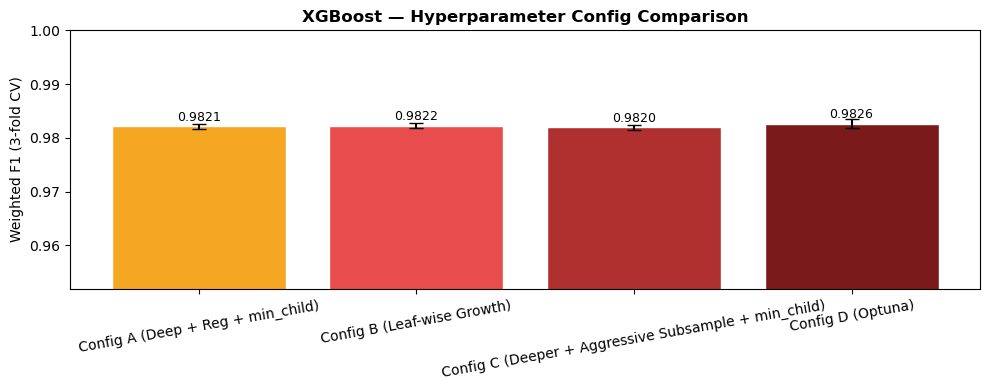

In [7]:
print('\n=== XGBoost Config Summary ===')
print(f'{"Config":<35} {"CV F1":>8}  {"Std":>7}')
print('-' * 55)
for name, (mean, std) in config_results.items():
    print(f'{name:<35} {mean:.4f}   {std:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
names = list(config_results.keys())
means = [config_results[n][0] for n in names]
stds  = [config_results[n][1] for n in names]
colors = ['#F5A623', '#E84C4C', '#B03030', '#7B1A1A']

bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors, edgecolor='white')
ax.set_ylim(min(means) - 0.03, 1.0)
ax.set_ylabel('Weighted F1 (3-fold CV)')
ax.set_title('XGBoost — Hyperparameter Config Comparison', fontweight='bold')
ax.tick_params(axis='x', rotation=10)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## Best Model Further Evaluation

In [8]:
xgb_eval = xgb.XGBClassifier(
    **study_xgb.best_params,
    objective='multi:softmax', num_class=3,
    eval_metric='mlogloss', tree_method='hist',
    n_jobs=1, random_state=SEED
)
xgb_eval.fit(X_tr, y_tr,
             sample_weight=compute_sample_weight('balanced', y_tr))
y_pred = xgb_eval.predict(X_val)

print(classification_report(y_val, y_pred, target_names=le.classes_))
print(f'Weighted F1 : {f1_score(y_val, y_pred, average="weighted"):.4f}')
print(f'Macro   F1  : {f1_score(y_val, y_pred, average="macro"):.4f}')

              precision    recall  f1-score   support

        High       0.95      0.94      0.94       205
         Low       0.98      0.99      0.99      3505
      Medium       0.98      0.97      0.98      2290

    accuracy                           0.98      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.98      0.98      0.98      6000

Weighted F1 : 0.9820
Macro   F1  : 0.9685


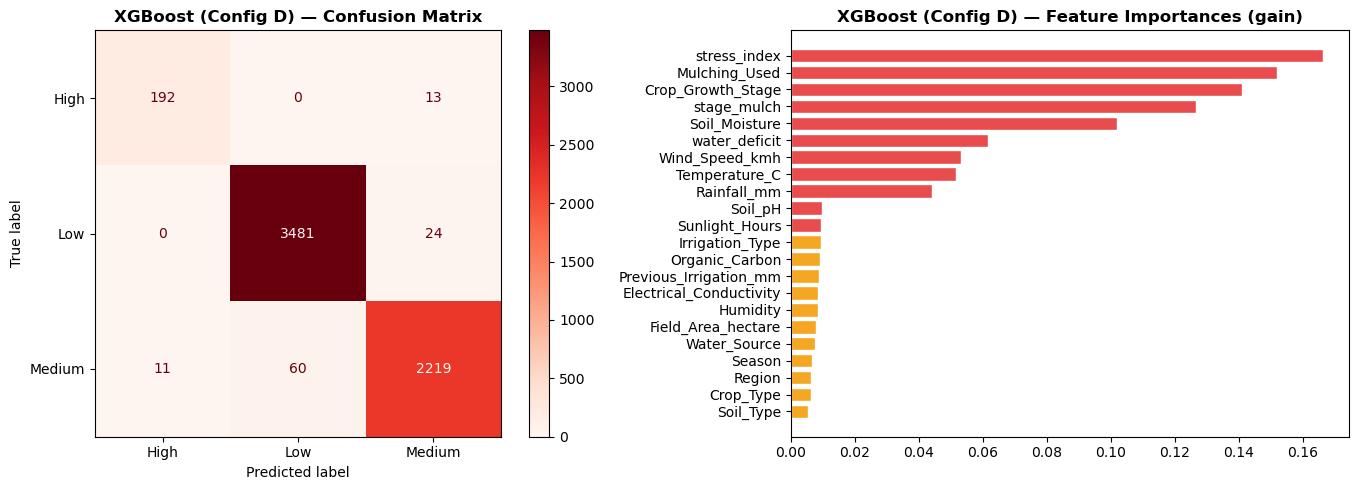

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred),
    display_labels=le.classes_
).plot(ax=axes[0], cmap='Reds')
axes[0].set_title('XGBoost (Config D) — Confusion Matrix', fontweight='bold')

imp = pd.Series(xgb_eval.feature_importances_, index=FEAT_COLS).sort_values()
c = ['#E84C4C' if v > imp.median() else '#F5A623' for v in imp]
axes[1].barh(imp.index, imp.values, color=c, edgecolor='white')
axes[1].set_title('XGBoost (Config D) — Feature Importances (gain)', fontweight='bold')

plt.tight_layout(); plt.show()

## Kaggle Submission


In [10]:
# Train on 200K sample (use full data on Kaggle if runtime allows)
full_idx = np.random.RandomState(SEED).choice(len(X), 200000, replace=False)

xgb_sub = xgb.XGBClassifier(
    **study_xgb.best_params,
    objective='multi:softmax', num_class=3,
    eval_metric='mlogloss', tree_method='hist',
    n_jobs=1, random_state=SEED
)
xgb_sub.fit(
    X[full_idx], y[full_idx],
    sample_weight=compute_sample_weight('balanced', y[full_idx])
)

submission = pd.DataFrame({
    'id':   test['id'],
    TARGET: le.inverse_transform(xgb_sub.predict(X_test))
})
submission.to_csv('submission_xgb_optuna.csv', index=False)
print('Saved: submission_xgb_optuna.csv')
print(submission[TARGET].value_counts())

Saved: submission_xgb_optuna.csv
Irrigation_Need
Low       159888
Medium    101344
High        8768
Name: count, dtype: int64
